# top

In [4]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# train model

In [22]:
# need a VAE
from b_models.vae.vae3 import VAE

params = {
    "input_dim": 64,
    "input_channel": 1,
    "hidden_channels": [64, 64],
    "z_dim": 4,
    "num_blocks": 1,
}
vae = VAE(**params)

In [6]:
# import circle in squares dataset
from a_datasets.circle_in_square.data import load_cis_data

tensors, (x, y) = load_cis_data()

In [23]:
# train the model on the data
test_img = tensors[0].unsqueeze(0)
print(test_img.shape)
out = vae(test_img)
print(out.shape)

torch.Size([1, 1, 64, 64])
torch.Size([1, 1, 64, 64])


# now train the model

In [24]:
from torch.utils.data import DataLoader

dataloader = DataLoader(tensors, batch_size=512, shuffle=True)

In [25]:
# now train model
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

vae.train()
vae.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
criterion = nn.MSELoss()
n_epochs = 350

# kl annealing schedule
kl_weight = 0.0
def kl_annealing(epoch, n_epochs_anneal, schedule='linear', end_value = 1.):
    if schedule == 'linear':
        if epoch < n_epochs_anneal:
            kl_weight = end_value * (epoch / n_epochs_anneal)
        else:
            kl_weight = end_value
    elif schedule == 'cosine':
        if epoch < n_epochs_anneal:
            # cosine annealing from 0 to 1
            kl_weight = (1 - 0.5 * (1 + np.cos(np.pi * epoch / n_epochs_anneal))) * end_value
        else:
            kl_weight = end_value
    elif schedule == "constant":
        kl_weight = end_value
    return kl_weight

for epoch in tqdm(range(n_epochs), miniterval=50):
    for batch in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        output = vae(batch)[0]
        mse_loss = criterion(output, batch)
        kl_weight = kl_annealing(epoch, 10, schedule='constant', end_value = 1e-7)
        # kl_weight = 1
        kl_loss = vae.kl
        # Combine losses
        loss = mse_loss + kl_loss * kl_weight
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0 or epoch < 10:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}, MSE Loss: {mse_loss.item():.4f}, KL weight: {kl_weight:.4f}, KL Loss: {kl_loss.item():.4f}")

  0%|                                                                                               | 0/350 [00:00<?, ?it/s]/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([512, 1, 64, 64])) that is different to the input size (torch.Size([1, 64, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([272, 1, 64, 64])) that is different to the input size (torch.Size([1, 64, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
  0%|▏                                                                                      | 1/350 [00:01<08:01,  1.38s

Epoch 1, Loss: 0.1978, MSE Loss: 0.1978, KL weight: 0.0000, KL Loss: 2.4765


  1%|▍                                                                                      | 2/350 [00:01<04:58,  1.17it/s]

Epoch 2, Loss: 0.1308, MSE Loss: 0.1308, KL weight: 0.0000, KL Loss: 3.6966


  1%|▋                                                                                      | 3/350 [00:02<04:00,  1.44it/s]

...

 95%|████████████████████████████████████████████████████████████████████████████████▍    | 331/350 [02:42<00:09,  2.04it/s]

Epoch 331, Loss: 0.0381, MSE Loss: 0.0381, KL weight: 0.0000, KL Loss: 20.9757


 97%|██████████████████████████████████████████████████████████████████████████████████▊  | 341/350 [02:47<00:04,  2.04it/s]

Epoch 341, Loss: 0.0387, MSE Loss: 0.0387, KL weight: 0.0000, KL Loss: 19.9250


100%|█████████████████████████████████████████████████████████████████████████████████████| 350/350 [02:52<00:00,  2.03it/s]


In [34]:
print(test_img.min(), test_img.max())

tensor(-1., device='cuda:0') tensor(1., device='cuda:0')


Test Loss: 0.9096


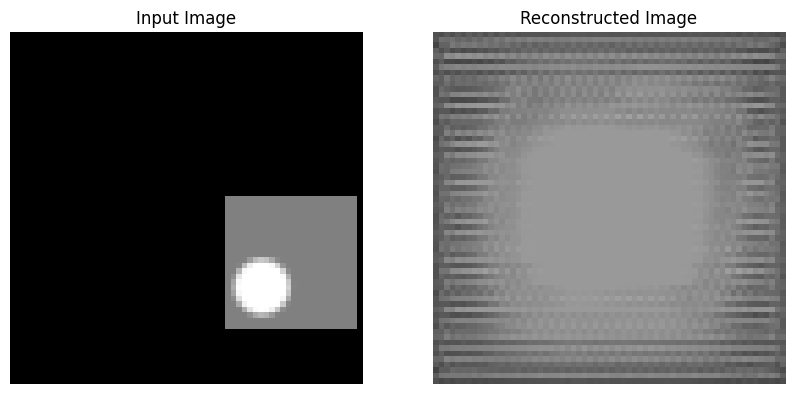

In [35]:
from utils.base_utils import to_01, to_0c
img_idx = 11

test_img = to_0c(tensors[img_idx]).unsqueeze(1).to(device)

vae.eval()
xout = vae(test_img)
xout = xout.detach().cpu()
xin = test_img.detach().cpu()

# print(xin.min(), xout.min(), xin.max(), xout.max())
test_loss = criterion(xin, xout).item()
print(f"Test Loss: {test_loss:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(to_01(xin).squeeze(0, 1), cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Input Image")
ax[0].axis("off");

ax[1].imshow(to_01(xout).squeeze(0, 1), cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Reconstructed Image")
ax[1].axis("off");

